In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
from pandas.io.stata import StataReader

In [3]:
# load data
DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"

cols_to_use = [
    "dataset", "Region", "MO5L", "SC5L", "UA5L", "PD5L", "AD5L", "EQvas", "srh", "sat", "mo2cat", "sc2cat",
    "ua2cat", "pd2cat", "ad2cat", "FULLHEALTH", "anyprob", "util_rowen", "LSS_rs", "EQ_index", "age7cat", "Sex",
    "eth4cat", "emp_cat", "edu_cat", "educ_pst", "smoke_ever", "smoke_ecig", "alcohol_yr", "diabetes",
    "obese", "resp", "bowel", "mus", "skin",
    # Disability / chronic illness — harmonised across HSE (numeric) and DAPHNIE (string)
    "DisabilityPhys", "DisabilityMent", "PhysicalDisability", "MentalDisability", "ILL12m",
    # Medications — harmonised across HSE (numed) and DAPHNIE (MedicationsQ1 / meds)
    "meds", "numed", "MedicationsQ1",
]

In [4]:
# Create reader object
reader = StataReader(DATA_PATH / 'Pop_Data_Appended_NoPopcorn.dta', columns=cols_to_use)

# Extract variable labels
var_labels = reader.variable_labels()

# Extract value labels
val_labels = reader.value_labels()

# Extract the entire dataset
df = reader.read()

/tmp/ipykernel_25619/127024535.py:5: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  var_labels = reader.variable_labels()
/tmp/ipykernel_25619/127024535.py:8: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  val_labels = reader.value_labels()


In [5]:
df.head()

,dataset,Region,MO5L,SC5L,UA5L,PD5L,AD5L,EQvas,srh,sat,...,mus,skin,DisabilityPhys,DisabilityMent,PhysicalDisability,MentalDisability,ILL12m,meds,numed,MedicationsQ1
0,HSE 2017,NaN,No Problems,No Problems,No Problems,No Problems,No Problems,100.0,Very good/Excellent,9.0,...,NaN,0.0,NaN,NaN,,,Yes,NaN,Not applicable,
1,HSE 2017,NaN,Slight,No Problems,No Problems,Moderate,Slight,75.0,Good/fair,7.0,...,NaN,0.0,NaN,NaN,,,Yes,NaN,Doesn't take prescribed meds,
2,HSE 2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fair/bad,NaN,...,NaN,0.0,NaN,NaN,,,Yes,NaN,Not applicable,
3,HSE 2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Very good/Excellent,NaN,...,NaN,0.0,NaN,NaN,,,No,NaN,2.0,
4,HSE 2017,NaN,No Problems,No Problems,No Problems,No Problems,No Problems,90.0,Very good/Good,9.0,...,NaN,0.0,NaN,NaN,,,No,NaN,Doesn't take prescribed meds,


# Exploratory Analysis

This section profiles the loaded dataframe with quick structural checks, missingness, summary tables, and a few diagnostic plots.

In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PLOTS_PATH.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_like_cols = [
    col for col in df.columns
    if df[col].dtype == "object" or df[col].nunique(dropna=True) <= 10
]
continuous_cols = [
    col for col in numeric_cols
    if col not in categorical_like_cols and df[col].nunique(dropna=True) > 10
]

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical-like columns: {len(categorical_like_cols)}")
print(f"Continuous columns: {len(continuous_cols)}")

Rows: 57,425
Columns: 43
Numeric columns: 12
Categorical-like columns: 38
Continuous columns: 5


In [7]:
overview = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
        "n_unique": df.nunique(dropna=True),
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

print("First five rows")
display(df.head())

print("Column overview")
display(overview)

missing_only = overview.loc[overview["missing"] > 0, ["missing", "missing_pct"]]
if not missing_only.empty:
    print("Columns with missing values")
    display(missing_only)
else:
    print("No missing values detected.")

First five rows


,dataset,Region,MO5L,SC5L,UA5L,PD5L,AD5L,EQvas,srh,sat,mo2cat,sc2cat,ua2cat,pd2cat,ad2cat,FULLHEALTH,anyprob,util_rowen,LSS_rs,EQ_index,age7cat,Sex,eth4cat,emp_cat,edu_cat,educ_pst,smoke_ever,smoke_ecig,alcohol_yr,diabetes,obese,resp,bowel,mus,skin,DisabilityPhys,DisabilityMent,PhysicalDisability,MentalDisability,ILL12m,meds,numed,MedicationsQ1
0,HSE 2017,NaN,No Problems,No Problems,No Problems,No Problems,No Problems,100.000,Very good/Excellent,9.000,No Problems,No Problems,No Problems,No Problems,No Problems,Full Health,No Problems,1.000,100.000,1.000,6.000,Male,White,Employed,Degree or equivalent,NaN,yes,no,monthly+,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,,,Yes,NaN,Not applicable,
1,HSE 2017,NaN,Slight,No Problems,No Problems,Moderate,Slight,75.000,Good/fair,7.000,Any Problems,No Problems,No Problems,Any Problems,Any Problems,Has problems,Has Problems,0.861,80.000,0.861,2.000,Female,White,Employed,Below degree,NaN,NaN,yes,weekly+,NaN,0.000,0.000,NaN,NaN,0.000,NaN,NaN,,,Yes,NaN,Doesn't take prescribed meds,
2,HSE 2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fair/bad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,-1.000,Female,White,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,,,Yes,NaN,Not applicable,
3,HSE 2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Very good/Excellent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,-1.000,Female,White,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,,,No,NaN,2.000,
4,HSE 2017,NaN,No Problems,No Problems,No Problems,No Problems,No Problems,90.000,Very good/Good,9.000,No Problems,No Problems,No Problems,No Problems,No Problems,Full Health,No Problems,1.000,100.000,1.000,3.000,Male,White,Employed,Degree or equivalent,NaN,NaN,no,weekly+,NaN,1.000,0.000,NaN,NaN,0.000,NaN,NaN,,,No,NaN,Doesn't take prescribed meds,


Column overview


,dtype,missing,missing_pct,n_unique
meds,category,52662,91.706,6
DisabilityPhys,category,52617,91.627,3
DisabilityMent,category,52614,91.622,3
Region,category,52187,90.879,4
bowel,float32,48171,83.885,2
diabetes,float32,47685,83.039,2
EQvas,float32,36568,63.680,101
EQ_index,float32,36234,63.098,659
LSS_rs,float32,36234,63.098,21
FULLHEALTH,category,36234,63.098,2


Columns with missing values


,missing,missing_pct
meds,52662,91.706
DisabilityPhys,52617,91.627
DisabilityMent,52614,91.622
Region,52187,90.879
bowel,48171,83.885
diabetes,47685,83.039
EQvas,36568,63.680
EQ_index,36234,63.098
LSS_rs,36234,63.098
FULLHEALTH,36234,63.098


Continuous-variable summary


,count,mean,std,min,25%,50%,75%,max
EQvas,"20,857.000",75.567,20.217,0.000,68.000,80.000,90.000,100.000
LSS_rs,"21,191.000",88.144,16.430,0.000,85.000,95.000,100.000,100.000
sat,"29,095.000",7.445,2.053,0.000,7.000,8.000,9.000,10.000
EQ_index,"21,191.000",0.864,0.227,-0.567,0.854,0.944,1.000,1.000
util_rowen,"38,004.000",0.923,0.184,-0.567,0.944,1.000,1.000,1.000


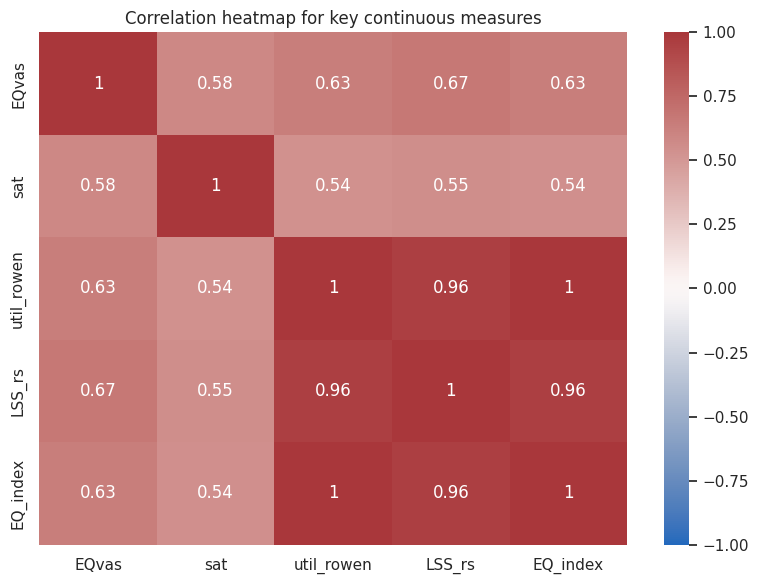

In [8]:
if continuous_cols:
    numeric_summary = df[continuous_cols].describe().T.sort_values("std", ascending=False)
    print("Continuous-variable summary")
    display(numeric_summary)

    corr_candidates = [
        col for col in ["EQvas", "srh", "sat", "util_rowen", "LSS_rs", "EQ_index"]
        if col in continuous_cols
    ]
    if len(corr_candidates) >= 2:
        corr = df[corr_candidates].corr(numeric_only=True)
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, cmap="vlag", vmin=-1, vmax=1)
        plt.title("Correlation heatmap for key continuous measures")
        plt.tight_layout()
        plt.savefig(PLOTS_PATH / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("No continuous columns detected with the current heuristic.")

In [9]:
if "Region" not in df.columns:
    raise KeyError("Region column is not available in the dataframe.")

original_rows = len(df)
missing_region = int(df["Region"].isna().sum())
non_england_rows = int(df["Region"].notna().sum() - df["Region"].eq("England").sum())

df["Region"] = df["Region"].astype("string").fillna("England")
df = df.loc[df["Region"] == "England"].copy()

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_like_cols = [
    col for col in df.columns
    if df[col].dtype == "object" or str(df[col].dtype) == "string" or df[col].nunique(dropna=True) <= 10
]
continuous_cols = [
    col for col in numeric_cols
    if col not in categorical_like_cols and df[col].nunique(dropna=True) > 10
]

print(f"Filled {missing_region:,} missing Region values with 'England'.")
print(f"Dropped {non_england_rows:,} rows that were not England.")
print(f"Rows retained: {len(df):,} of {original_rows:,}")
print(df["Region"].value_counts(dropna=False))

df = df.drop(columns=["Region"], inplace=False)

Filled 52,187 missing Region values with 'England'.
Dropped 738 rows that were not England.
Rows retained: 56,687 of 57,425
Region
England    56687
Name: count, dtype: Int64


In [10]:
df['dataset'] = df['dataset'].apply(lambda x: 'DAPHNIE 2023' if 'Pilot' in x else x)

In [11]:
if "diabetes" not in df.columns:
    raise KeyError("diabetes column is not available in the dataframe.")

missing_diabetes = int(df["diabetes"].isna().sum())
diabetes_series = df["diabetes"]

if isinstance(diabetes_series.dtype, pd.CategoricalDtype):
    if 0 not in diabetes_series.cat.categories and 0.0 not in diabetes_series.cat.categories:
        diabetes_series = diabetes_series.cat.add_categories([0.0])
    df["diabetes"] = diabetes_series.fillna(0.0)
else:
    df["diabetes"] = diabetes_series.fillna(0)

print(f"Filled {missing_diabetes:,} missing diabetes values with 0.")
print(df["diabetes"].value_counts(dropna=False))

Filled 47,628 missing diabetes values with 0.
diabetes
0.000    53526
1.000     3161
Name: count, dtype: int64


In [12]:
if "age7cat" not in df.columns:
    raise KeyError("age7cat column is not available in the dataframe.")

age7cat_numeric = pd.to_numeric(df["age7cat"], errors="coerce")
drop_mask = age7cat_numeric.isin([-1, 0])
dropped_age7cat_rows = int(drop_mask.sum())
rows_before_age7cat_filter = len(df)

df = df.loc[~drop_mask].copy()

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_like_cols = [
    col for col in df.columns
    if df[col].dtype == "object" or str(df[col].dtype) == "string" or df[col].nunique(dropna=True) <= 10
]
continuous_cols = [
    col for col in numeric_cols
    if col not in categorical_like_cols and df[col].nunique(dropna=True) > 10
]

print(f"Dropped {dropped_age7cat_rows:,} rows where age7cat was -1 or 0.")
print(f"Rows retained: {len(df):,} of {rows_before_age7cat_filter:,}")
print(df["age7cat"].value_counts(dropna=False).sort_index())

Dropped 7,546 rows where age7cat was -1 or 0.
Rows retained: 49,141 of 56,687
age7cat
1.000    3405
2.000    6010
3.000    7438
4.000    7513
5.000    7866
6.000    7853
7.000    5085
NaN      3971
Name: count, dtype: int64


## Variable Harmonisation: Disability, Chronic Illness, and Medications

HSE and DAPHNIE measured the same constructs with different instruments:

| Construct | HSE source | DAPHNIE source |
|---|---|---|
| Physical disability | `DisabilityPhys` (0/1/2) | `PhysicalDisability` ("Y"/"N"/"NA") |
| Mental disability | `DisabilityMent` (0/1/2) | `MentalDisability` ("Y"/"N"/"NA") |
| Chronic illness | `ILL12m` (1=yes / 2=no) | covered by DisabilityPhys/Ment |
| Medication count | `numed` (0–4+) | `MedicationsQ1` ("A1"–"A6") / `meds` |

The approach is to fill the HSE numeric variables from the DAPHNIE string variables **only where the numeric variable is missing**, then construct two unified variables:

- **`ill_dis`** — binary flag: any physical or mental disability, or chronic illness lasting 12+ months  
- **`meds_num`** — ordinal medication count: 0 / 1 / 2 / 3+ (capped to reduce sparsity at the top)

In [18]:
# --- Disability harmonisation ---
# DisabilityPhys/Ment and ILL12m are integer variables with Stata value labels,
# so pandas loads them as Categorical dtype ("No"/"Yes"/"Don't know" etc.).
# We reverse-map them to float using val_labels before any assignment.

str_to_num = {"Y": 1.0, "N": 0.0, "NA": np.nan}

for num_col, str_col in [("DisabilityPhys", "PhysicalDisability"), ("DisabilityMent", "MentalDisability")]:
    if isinstance(df[num_col].dtype, pd.CategoricalDtype):
        reverse_map = {label: float(code) for code, label in val_labels[num_col].items()}
        df[num_col] = df[num_col].map(reverse_map)

    # Fill from DAPHNIE string variable where missing (HSE rows are already populated)
    missing_mask = df[num_col].isna()
    df.loc[missing_mask, num_col] = (
        df.loc[missing_mask, str_col].astype(str).str.strip().map(str_to_num)
    )
    # "Don't know" (code 2) → NaN
    df.loc[df[num_col] == 2.0, num_col] = np.nan

# ILL12m is also value-labelled → convert before comparison
if isinstance(df["ILL12m"].dtype, pd.CategoricalDtype):
    reverse_map = {label: float(code) for code, label in val_labels["ILL12m"].items()}
    df["ILL12m"] = df["ILL12m"].map(reverse_map)

# --- ill_dis: unified disability / chronic illness flag ---
# Default 0; set 1 if either disability is present; NaN only if both sources are missing.
# ILL12m (HSE 2019/2022, which lack the disability questions) overrides last.
df["ill_dis"] = 0.0
df.loc[(df["DisabilityPhys"] == 1) | (df["DisabilityMent"] == 1), "ill_dis"] = 1.0
df.loc[df["DisabilityPhys"].isna() & df["DisabilityMent"].isna(), "ill_dis"] = np.nan

df.loc[df["ILL12m"] == 1, "ill_dis"] = 1.0
df.loc[df["ILL12m"] == 2, "ill_dis"] = 0.0
df.loc[df["ILL12m"].notna() & (df["ILL12m"] < 0), "ill_dis"] = np.nan

print("ill_dis distribution")
print(df["ill_dis"].value_counts(dropna=False).rename({0.0: "No", 1.0: "Yes"}).sort_index())
print("\nill_dis by dataset")
display(pd.crosstab(df["dataset"], df["ill_dis"].map({0.0: "No", 1.0: "Yes"}).fillna("Missing"), margins=False))

ill_dis distribution
ill_dis
No      1083
Yes      453
NaN    47605
Name: count, dtype: int64

ill_dis by dataset


ill_dis,Missing,No,Yes
dataset,,,
HSE 2017,7997,0,0
HSE 2018,8178,0,0
HSE 2019,8204,0,0
HSE 2022,7729,0,0
DAPHNIE 2023,648,1083,453
DAPHNIE 2024,14849,0,0


In [21]:
df_ill = pd.read_stata(
    DATA_PATH / 'Pop_Data_Appended_NoPopcorn.dta', 
    columns=["DisabilityPhys", "DisabilityMent", "ILL12m"]
)
# --- Frequency tables (equivalent to 'fre') ---
def fre(df, col):
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

fre(df, 'DisabilityPhys')
fre(df, 'DisabilityMent') 

/tmp/ipykernel_25619/2336359075.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df_ill = pd.read_stata(



--- DisabilityPhys ---
DisabilityPhys
NaN      47620
0.000     1184
1.000      337
Name: count, dtype: int64

--- DisabilityMent ---
DisabilityMent
NaN      47636
0.000     1252
1.000      253
Name: count, dtype: int64


In [22]:
# --- encode: convert string columns to categorical codes ---
df['disPhys2'] = df['DisabilityPhys'].astype('category').cat.codes
df['disMent2'] = df['DisabilityMent'].astype('category').cat.codes
# Note: .cat.codes assigns -1 to NaN. Stata's encode starts at 1.
# Adjust category mappings if you know the exact label order.

fre(df, 'disPhys2')
fre(df, 'disMent2')


--- disPhys2 ---
disPhys2
-1    47620
 0     1184
 1      337
Name: count, dtype: int64

--- disMent2 ---
disMent2
-1    47636
 0     1252
 1      253
Name: count, dtype: int64


In [23]:
# --- Replace DisabilityPhys ---
# Stata's .a (inapplicable) is represented here as pd.NA
# You may want a separate column to track .a vs . if that distinction matters

mask_phys_missing = df['DisabilityPhys'].isna()

df.loc[(df['disPhys2'] == 4) & mask_phys_missing, 'DisabilityPhys'] = 1
df.loc[(df['disPhys2'] == 2) & mask_phys_missing, 'DisabilityPhys'] = 0
df.loc[(df['disPhys2'] == 3) & mask_phys_missing, 'DisabilityPhys'] = pd.NA  # .a → NA
df.loc[df['DisabilityPhys'] == 2, 'DisabilityPhys'] = pd.NA                  # .a → NA

# --- Replace DisabilityMent ---
mask_ment_missing = df['DisabilityMent'].isna()

df.loc[(df['disMent2'] == 4) & mask_ment_missing, 'DisabilityMent'] = 1
df.loc[(df['disMent2'] == 2) & mask_ment_missing, 'DisabilityMent'] = 0
df.loc[(df['disMent2'] == 3) & mask_ment_missing, 'DisabilityMent'] = pd.NA  # .a → NA
df.loc[df['DisabilityMent'] == 2, 'DisabilityMent'] = pd.NA                  # .a → NA

# --- Cross-tabulations (equivalent to 'tab x y, missing') ---
print(pd.crosstab(df['DisabilityMent'], df['disMent2'], dropna=False, margins=True))
print(pd.crosstab(df['DisabilityPhys'], df['DisabilityMent'], dropna=False, margins=True))

# --- Generate composite ill_dis variable ---
df['ill_dis'] = 0

df.loc[
    (df['DisabilityPhys'] == 1) | (df['DisabilityMent'] == 1),
    'ill_dis'
] = 1

df.loc[
    df['DisabilityPhys'].isna() & df['DisabilityMent'].isna(),
    'ill_dis'
] = pd.NA

# --- Frequency check ---
fre(df, 'ILL12m')

# --- Incorporate ILL12m into ill_dis ---
df.loc[df['ILL12m'] == 1, 'ill_dis'] = 1
df.loc[df['ILL12m'] == 2, 'ill_dis'] = 0
df.loc[df['ILL12m'] < 0,  'ill_dis'] = pd.NA

# --- Value labels: map 0/1 to yes/no for display ---
yesno = {0: 'no', 1: 'yes'}
df['ill_dis_labeled'] = df['ill_dis'].map(yesno)

# --- Final cross-tabs ---
print(pd.crosstab(df['ill_dis'], df['DisabilityPhys'], dropna=False, margins=True))
print(pd.crosstab(df['ill_dis'], df['DisabilityMent'], dropna=False, margins=True))

disMent2           -1     0    1    All
DisabilityMent                         
0.000               0  1252    0   1252
1.000               0     0  253    253
 NaN            47636     0    0  47636
 All            47636  1252  253  49141
DisabilityMent  0.000  1.000    NaN    All
DisabilityPhys                            
0.000            1045    112     27   1184
1.000             196    137      4    337
 NaN               11      4  47605  47620
 All             1252    253  47636  49141

--- ILL12m ---
ILL12m
NaN    49141
Name: count, dtype: int64
DisabilityPhys  0.000  1.000    NaN    All
ill_dis                                   
0.000            1072      0     11   1083
1.000             112    337      4    453
 NaN                0      0  47605  47605
 All             1184    337  47620  49141
DisabilityMent  0.000  1.000    NaN    All
ill_dis                                   
0.000            1056      0     27   1083
1.000             196    253      4    453
 NaN      

In [19]:
# --- Medications harmonisation ---
# Step 1: decode MedicationsQ1 (DAPHNIE pilot string) to the same 0–5 scale as `meds`.
# A1=0 meds, A2=1, A3=2, A4=3 (3-4), A5=4 (5-9), A6=5 (10+); "NA" and blanks → NaN.
meds_q1_map = {"A1": 0.0, "A2": 1.0, "A3": 2.0, "A4": 3.0, "A5": 4.0, "A6": 5.0}
df["meds_pilot"] = df["MedicationsQ1"].astype(str).str.strip().map(meds_q1_map)

# Step 2: fill missing `meds` from the pilot-decoded values.
df["meds"] = df["meds"].where(df["meds"].notna(), df["meds_pilot"])

# Step 3: meds_num — ordinal 0/1/2/3+ starting from `numed` (HSE continuous count).
# Fill from `meds` where numed is missing, then cap everything at 3.
# Negative codes in numed (-1=not applicable, -8=don't know, -9=refused) → NaN.
meds_to_num = {0.0: 0.0, 1.0: 1.0, 2.0: 2.0, 3.0: 3.0, 4.0: 3.0, 5.0: 3.0, 6.0: 3.0}
df["meds_num"] = df["numed"].copy()

fill_mask = df["meds_num"].isna()
df.loc[fill_mask, "meds_num"] = df.loc[fill_mask, "meds"].map(meds_to_num)

df.loc[df["meds_num"] >= 4, "meds_num"] = 3.0
df.loc[df["meds_num"] < 0, "meds_num"] = np.nan

df["meds_num"] = df["meds_num"].map({0.0: "none", 1.0: "1 med", 2.0: "2 meds", 3.0: "3+ meds"})

print("meds_num distribution")
print(df["meds_num"].value_counts(dropna=False))
print("\nmeds_num by dataset")
display(pd.crosstab(df["dataset"], df["meds_num"].fillna("Missing"), margins=False))

TypeError: Cannot setitem on a Categorical with a new category, set the categories first

## Categorical Variables

This block profiles categorical and categorical-like variables, highlights missingness and class imbalance, and compares their distributions across datasets when available.

In [ ]:
priority_categoricals = [
    column
    for column in [
        "dataset", "Sex", "age7cat", "eth4cat", "emp_cat", "edu_cat", "educ_pst",
        "smoke_ever", "smoke_ecig", "alcohol_yr", "diabetes", "obese", "resp", "bowel", "mus", "skin",
        "MO5L", "SC5L", "UA5L", "PD5L", "AD5L", "mo2cat", "sc2cat", "ua2cat", "pd2cat", "ad2cat",
        "FULLHEALTH", "anyprob"
    ]
    if column in categorical_like_cols
]
if not priority_categoricals:
    priority_categoricals = categorical_like_cols[:12]


def category_display_series(series):
    return series.astype("string").fillna("Missing")


def top_category_stats(series):
    counts = category_display_series(series).value_counts(dropna=False)
    top_value = counts.index[0]
    top_count = int(counts.iloc[0])
    top_pct = float(counts.iloc[0] / len(series) * 100)
    return top_value, top_count, top_pct


summary_rows = []
for column in priority_categoricals:
    top_value, top_count, top_pct = top_category_stats(df[column])
    summary_rows.append(
        {
            "column": column,
            "label": var_labels.get(column, column),
            "dtype": str(df[column].dtype),
            "missing": int(df[column].isna().sum()),
            "missing_pct": float(df[column].isna().mean() * 100),
            "n_unique": int(df[column].nunique(dropna=True)),
            "top_value": top_value,
            "top_count": top_count,
            "top_pct": top_pct,
        }
    )

category_summary = (
    pd.DataFrame(summary_rows)
    .set_index("column")
    .sort_values(["missing_pct", "top_pct", "n_unique"], ascending=[False, False, True])
)

print("Categorical-variable summary")
display(category_summary)

In [ ]:
plot_categoricals = [
    column
    for column in category_summary.index
    if 1 < df[column].nunique(dropna=True) <= 8
][:6]

if plot_categoricals:
    n_cols = 2
    n_rows = math.ceil(len(plot_categoricals) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for axis, column in zip(axes, plot_categoricals):
        counts = category_display_series(df[column]).value_counts(dropna=False)
        sns.barplot(x=counts.values, y=counts.index, ax=axis, color="#4C78A8")
        axis.set_title(var_labels.get(column, column))
        axis.set_xlabel("Count")
        axis.set_ylabel(column)

        for idx, value in enumerate(counts.values):
            axis.text(value, idx, f" {value / len(df):.1%}", va="center")

    for axis in axes[len(plot_categoricals):]:
        axis.remove()

    plt.tight_layout()
    plt.savefig(PLOTS_PATH / "categorical_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No categorical variables met the plotting heuristic.")

In [ ]:
if "dataset" in df.columns:
    comparison_categoricals = [column for column in plot_categoricals if column != "dataset"][:4]

    if comparison_categoricals:
        dataset_series = category_display_series(df["dataset"])

        for column in comparison_categoricals:
            print(f"Distribution of {column} within each dataset")
            display(
                pd.crosstab(
                    dataset_series,
                    category_display_series(df[column]),
                    normalize="index",
                    dropna=False,
                ).round(3)
            )
    else:
        print("No categorical variables were eligible for a dataset comparison table.")
else:
    print("The dataframe does not contain a dataset column for grouped categorical comparisons.")

## Dataset Bias Diagnostics

This section checks whether the concatenated datasets differ systematically in sample composition, missingness, and feature patterns. A strong ability to predict dataset membership from the remaining variables is evidence of dataset-specific bias or batch effects.

In [ ]:
if "dataset" not in df.columns:
    raise KeyError("dataset column is not available in the dataframe.")

bias_dataset_counts = (
    df["dataset"]
    .value_counts(dropna=False)
    .rename_axis("dataset")
    .to_frame("n_rows")
)
bias_dataset_counts["share_pct"] = bias_dataset_counts["n_rows"].div(len(df)).mul(100).round(2)

print("Dataset composition")
display(bias_dataset_counts)

bias_missingness = pd.DataFrame(
    {
        dataset_name: df.loc[df["dataset"] == dataset_name].isna().mean().mul(100)
        for dataset_name in bias_dataset_counts.index
    }
).T

bias_missing_gap = (bias_missingness.max(axis=0) - bias_missingness.min(axis=0)).sort_values(ascending=False)
bias_missing_summary = pd.DataFrame(
    {
        "overall_missing_pct": df.isna().mean().mul(100),
        "between_dataset_gap_pct": bias_missing_gap,
    }
).sort_values(["between_dataset_gap_pct", "overall_missing_pct"], ascending=False)

print("Columns with the largest between-dataset missingness gaps")
display(bias_missing_summary.head(15).round(2))

bias_heatmap_cols = bias_missing_summary.head(12).index.tolist()
if bias_heatmap_cols:
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        bias_missingness[bias_heatmap_cols],
        annot=True,
        fmt=".1f",
        cmap="Reds",
        cbar_kws={"label": "Missing (%)"},
    )
    plt.title("Missingness by dataset for the most heterogeneous variables")
    plt.xlabel("Variable")
    plt.ylabel("Dataset")
    plt.tight_layout()
    plt.savefig(PLOTS_PATH / "dataset_missingness_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
df.to_csv(DATA_PATH / "processed_data.csv", index=False, sep="\t")